In [1]:
from scipy.signal import find_peaks
from astropy.io import fits
from specutils import Spectrum1D
import matplotlib.pyplot as plt
import numpy as np
from astropy import units as u
import requests
from io import BytesIO
import os
import csv


In [2]:
def inject_and_plot_laser(obj_id, filt, folder="/datax/scratch/emmay/galah_spectra",
                          fwhm=1.5, laser_amp_percent=20, plot=True):
    """
    Injects a Gaussian laser spike into GALAH FITS spectrum and plots it.

    Parameters:
        obj_id (str): Object ID
        filt (str): Filter (e.g. 'B', 'V', 'R', 'I')
        folder (str): Path to FITS files
        fwhm (float): FWHM of the Gaussian in pixels
        laser_amp_percent (float): Amplitude of injection as percentage of max flux
        plot (bool): Whether to show the plot

    Returns:
        wavelength (np.ndarray): Wavelength array (in Å)
        flux_injected (np.ndarray): Flux array with injected Gaussian
    """
    filename = f"{obj_id}_{filt}.fits"
    path = os.path.join(folder, filename)

    with fits.open(path) as hdul:
        header = hdul[1].header
        flux = hdul[1].data.astype(float)

    # Build wavelength axis
    crval1 = header.get('CRVAL1')
    cdelt1 = header.get('CDELT1')
    crpix1 = header.get('CRPIX1', 1)

    npix = len(flux)
    wavelength = (crval1 + (np.arange(npix) + 1 - crpix1) * cdelt1) * u.AA

    # Inject Gaussian
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))
    center = npix // 2
    x = np.arange(npix)
    gaussian = np.exp(-0.5 * ((x - center) / sigma) ** 2)
    gaussian *= (laser_amp_percent / 100.0) * np.nanmax(flux)

    flux_injected = flux + gaussian

    # Plot
    if plot:
        threshold_mask = gaussian > 1e-4
        plt.figure(figsize=(13, 5))
        plt.plot(wavelength, flux, color='blue', linewidth=0.6, label="Original Spectrum")
        plt.plot(wavelength[threshold_mask], flux_injected[threshold_mask], color='red', linewidth=1.0, label="Injected Region")
        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        plt.title(f"Injected Spectrum — {obj_id} ({filt}) — Amplitude = {laser_amp_percent}%")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return wavelength.value, flux, flux_injected, wavelength[center]


In [3]:
import os
import numpy as np
from astropy.io import fits

def get_flux_wl(obj_id, filt, folder="/datax/scratch/emmay/galah_spectra"):
    """
    Reads a GALAH FITS spectrum and returns the wavelength and flux arrays.

    Parameters:
        obj_id (str): Object ID
        filt (str): Filter (e.g. 'B', 'V', 'R', 'I')
        folder (str): Path to FITS files

    Returns:
        wavelength (np.ndarray): Wavelength array (in Å, plain float array)
        flux (np.ndarray): Flux array
    """
    filename = f"{obj_id}_{filt}.fits"
    path = os.path.join(folder, filename)

    with fits.open(path) as hdul:
        header = hdul[1].header
        flux = hdul[1].data.astype(float)

    crval1 = header.get('CRVAL1')
    cdelt1 = header.get('CDELT1')
    crpix1 = header.get('CRPIX1', 1)

    npix = len(flux)
    wavelength = crval1 + (np.arange(npix) + 1 - crpix1) * cdelt1

    return wavelength, flux

## Find Peak

In [4]:

def measure_width_at_y(flux, wavelength, peak_idx, y_level=1):
    """Measure width of a peak at a fixed y_level using linear interpolation."""
    # Left side
    i = peak_idx
    while i > 0 and flux[i] > y_level:
        i -= 1
    if i == 0 or flux[i] > y_level:
        return None  # No valid left edge
    left = wavelength[i] + (y_level - flux[i]) / (flux[i+1] - flux[i]) * (wavelength[i+1] - wavelength[i])

    # Right side
    i = peak_idx
    while i < len(flux) - 1 and flux[i] > y_level:
        i += 1
    if i == len(flux) - 1 or flux[i] > y_level:
        return None  # No valid right edge
    right = wavelength[i-1] + (y_level - flux[i-1]) / (flux[i] - flux[i-1]) * (wavelength[i] - wavelength[i-1])

    return left, right, right - left

In [5]:
def detect_laser_peak_with_fixed_level_width(
    wavelength, 
    flux, 
    height_fraction=0.2, # absolute number, not percentage of max flux, threshold = 1+height_fraction
    y_level=1.0, 
    max_width_aa=3.0,  # max peak width in Angstroms (was max_pixel_width)
    injected_wavelength=None,
    plot=True
):
    flux = np.asarray(flux)
    wavelength = np.asarray(wavelength)

    # Height threshold: fraction of max flux above continuum (assumed ~1)
    height_threshold = 1 + height_fraction #* np.nanmax(np.abs(flux - 1))
    peak_indices, properties = find_peaks(flux, height=height_threshold)

    if len(peak_indices) == 0:
        if plot:
            plt.figure(figsize=(12, 4))
            plt.plot(wavelength, flux, label="Full Spectrum")
            if injected_wavelength is not None:
                plt.axvline(x=float(injected_wavelength.value), color='r', linestyle='--', linewidth=2, label="Injected Laser")
            plt.xlabel("Wavelength (Å)")
            plt.ylabel("Flux")
            plt.title("Full Spectrum (No Peaks Detected)")
            plt.legend()
            plt.tight_layout()
            plt.show()
        return [], [], []

    peak_wavelengths = []
    peak_fluxes = []
    widths = []
    valid_peak_indices = []

    for i, idx in enumerate(peak_indices):
        result = measure_width_at_y(flux, wavelength, idx, y_level=y_level)
        if result is not None:
            left, right, width = result

            if width > max_width_aa:
                continue

            peak_wavelengths.append(wavelength[idx])
            peak_fluxes.append(flux[idx])
            widths.append(width)
            valid_peak_indices.append(idx)

            if plot:
                i_min = max(0, idx - 20)
                i_max = min(len(wavelength), idx + 20)

                plt.figure(figsize=(10, 4))
                plt.plot(wavelength[i_min:i_max], flux[i_min:i_max], label="Flux")
                plt.axvline(left, color='C2', linestyle='--')
                plt.axvline(right, color='C2', linestyle='--')
                plt.hlines(y_level, left, right, color='C3', linewidth=2, label=f'Width @ y={y_level}')
                plt.plot(wavelength[idx], flux[idx], 'rx', label="Peak Center")
                plt.xlabel("Wavelength (Å)")
                plt.ylabel("Flux")
                plt.title(f"Zoomed Peak at {wavelength[idx]:.2f} Å, Width = {width:.3f} Å")
                plt.legend()
                plt.tight_layout()
                plt.show()

    if plot and valid_peak_indices:
        plt.figure(figsize=(12, 4))
        plt.plot(wavelength, flux, label="Full Spectrum")
        for idx in valid_peak_indices:
            plt.plot(wavelength[idx], flux[idx], 'rx', label="Detected Peaks")

        if injected_wavelength is not None:
            plt.axvline(x=float(injected_wavelength.value), color='black', linestyle='--', linewidth=2, label="Injected Laser")

        plt.xlabel("Wavelength (Å)")
        plt.ylabel("Flux")
        plt.title("Full Spectrum with Detected Peaks")
        plt.legend()
        plt.tight_layout()
        plt.show()

    return peak_wavelengths, peak_fluxes, widths

## Find Peaks Only Loop for Multiple Objects

In [6]:
import os
import csv
from tqdm import tqdm
from astropy.io.fits.verify import VerifyError

folder = "/datax/scratch/emmay/galah_spectra"
fits_files = [f for f in os.listdir(folder) if f.endswith(".fits")]

results = []
errors = []  # collect errors instead of printing them inline
skipped = []  # missing/invalid fits files, tracked separately

for fits_file in tqdm(fits_files[:4000], desc="Detecting peaks"):
    filename_no_ext = fits_file[:-5]
    obj_id = filename_no_ext[:15]
    filt = filename_no_ext[16:]

    path = os.path.join(folder, fits_file)

    # Skip missing or empty files before even trying to open them
    if not os.path.exists(path) or os.path.getsize(path) == 0:
        skipped.append((fits_file, "missing or empty file"))
        continue

    try:
        # Step 1: Read original spectrum (no injection)
        wave, flux = get_flux_wl(obj_id, filt, folder=folder)

        # Step 2: Try to detect peaks
        peak_wavelengths, peak_fluxes, widths = detect_laser_peak_with_fixed_level_width(
            wave, flux, height_fraction=0.15, y_level=1.0,  max_width_aa=0.2, plot=False
        )

        # Step 3: Save results for each detected peak
        for wl, fl, w in zip(peak_wavelengths, peak_fluxes, widths):
            results.append({
                "obj_id": obj_id,
                "filt": filt,
                "peak_wavelength": wl,
                "peak_flux": fl,
                "peak_width": w
            })

    except (FileNotFoundError, OSError, VerifyError) as e:
        # Missing file, corrupted/invalid FITS structure, etc. — skip silently
        skipped.append((fits_file, str(e)))
        continue

    except Exception as e:
        # Anything else (e.g. bad header keywords, unexpected data shape) — log it
        errors.append((fits_file, str(e)))

output_path = os.path.join(folder, "detected_peaks", "h15_w02_noninjected_detected_peaks.csv")
with open(output_path, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["obj_id", "filt", "peak_wavelength", "peak_flux", "peak_width"])
    writer.writeheader()
    writer.writerows(results)

print(f"Saved {len(results)} detected peaks to {output_path}")
if skipped:
    print(f"{len(skipped)} files skipped (missing/invalid — see `skipped` list for details)")
if errors:
    print(f"{len(errors)} files failed with other errors (see `errors` list for details)")

Detecting peaks:  38%|███▊      | 1504/4000 [00:11<00:18, 134.91it/s]


KeyboardInterrupt: 

# Stats of Noninjected Detections

Loaded 44762 detected peaks
Blue: 21627 detections in range
Blue: 21627 total detections | bins ≥ 3 counts: 37
Green: 9300 detections in range
Green: 9300 total detections | bins ≥ 3 counts: 44
Red: 4790 detections in range
Red: 4790 total detections | bins ≥ 3 counts: 51
IR: 8268 detections in range
IR: 8268 total detections | bins ≥ 3 counts: 60


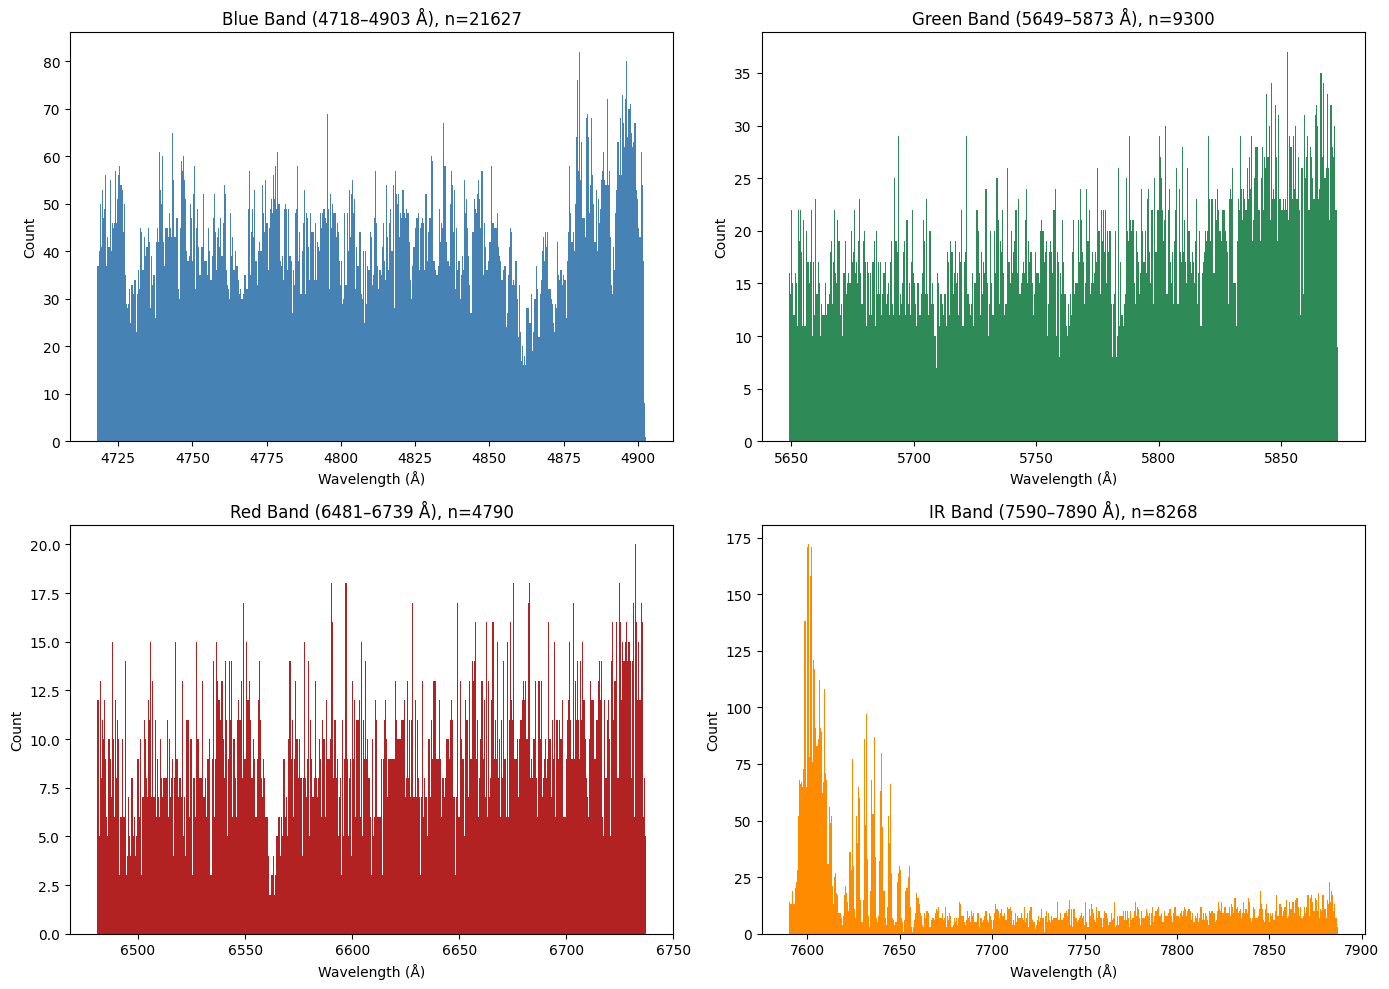

In [28]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Load the results
csv_path = "/datax/scratch/emmay/galah_spectra/detected_peaks/h15_w02_noninjected_detected_peaks.csv"
df = pd.read_csv(csv_path)

print(f"Loaded {len(df)} detected peaks")

# Define bands in Angstroms (converted from nm, 1 nm = 10 Å)
bands = {
    "Blue": (4718, 4903),
    "Green": (5649, 5873),
    "Red": (6481, 6739),
    "IR": (7590, 7890),
}

colors = {
    "Blue": "steelblue",
    "Green": "seagreen",
    "Red": "firebrick",
    "IR": "darkorange",
}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for ax, (band_name, (lam_min, lam_max)) in zip(axes, bands.items()):
    band_df = df[(df["peak_wavelength"] >= lam_min) & (df["peak_wavelength"] <= lam_max)]
    num_bins = int((lam_max - lam_min) / 5)

    counts, bin_edges = np.histogram(band_df["peak_wavelength"], bins=num_bins, range=(lam_min, lam_max))
    bins_above_threshold = np.sum(counts >= 3)

    ax.hist(band_df["peak_wavelength"], bins=500, color=colors[band_name])
    ax.set_xlabel("Wavelength (Å)")
    ax.set_ylabel("Count")
    ax.set_title(f"{band_name} Band ({lam_min}–{lam_max} Å), n={len(band_df)}")

    print(f"{band_name}: {len(band_df)} detections in range")
    print(f"{band_name}: {len(band_df)} total detections | bins ≥ 3 counts: {bins_above_threshold}")

plt.tight_layout()
plt.show()

In [29]:
from astropy.table import Table

band_results = []

for band_name, (lam_min, lam_max) in bands.items():
    band_df = df[(df["peak_wavelength"] >= lam_min) & (df["peak_wavelength"] <= lam_max)]

    num_bins = int((lam_max - lam_min) / 2)
    counts, bin_edges = np.histogram(band_df["peak_wavelength"], bins=num_bins, range=(lam_min, lam_max))
    bins_above_threshold = int(np.sum(counts >= 3))

    band_results.append({
        "Band": band_name,
        #"λmin (Å)": lam_min,
        #"λmax (Å)": lam_max,
        #"Total Detections": len(band_df),
        "Total Bins": num_bins,
        "Number of Bins ≥ 3 counts": bins_above_threshold,
    })

table = Table(rows=band_results)
print(table)


 Band Total Bins Number of Bins ≥ 3 counts
----- ---------- -------------------------
 Blue         92                        92
Green        112                       112
  Red        129                       129
   IR        150                       149


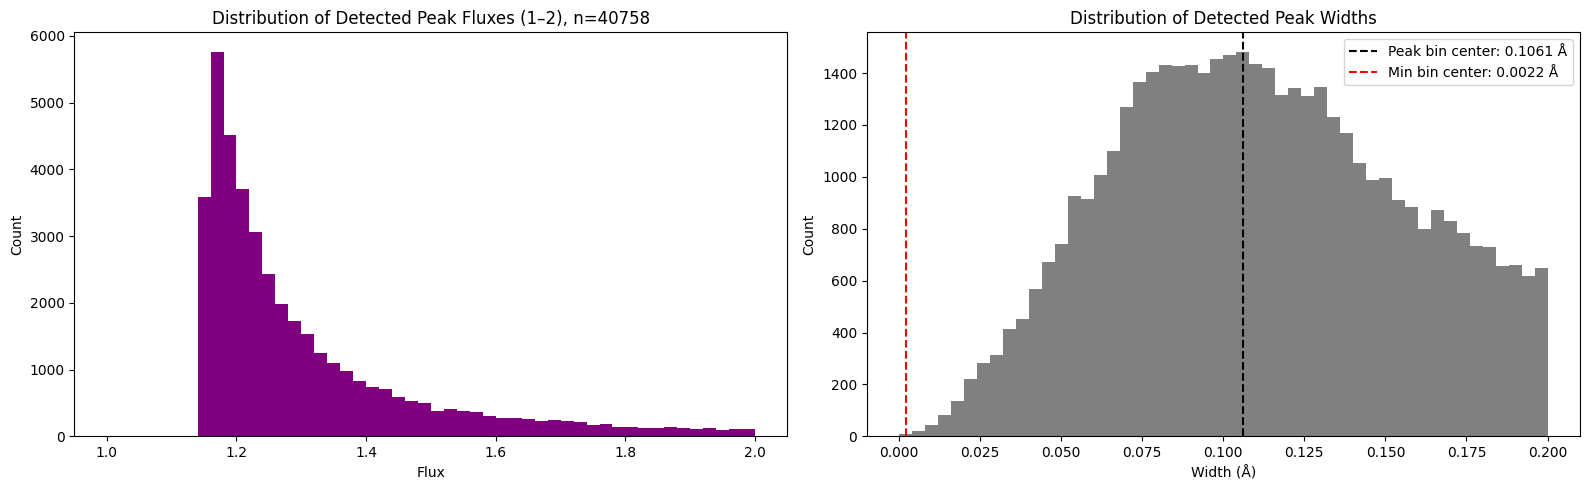


4004 data points outside range (flux > 200):
         obj_id filt  peak_wavelength   peak_flux  peak_width
161118002501129    B      4841.916033    3.026956    0.135114
161118002501129    I      7599.485727    2.215486    0.169773
161118002501129    I      7599.780065    3.687984    0.163989
161118002501129    I      7603.091363    2.548253    0.112877
140708007101168    B      4785.668341    2.663340    0.196701
140708007101168    I      7600.472640    2.009339    0.142751
170910004101382    B      4779.239137    2.105183    0.125703
170910004101382    I      7604.594471    3.162412    0.187377
171027001601281    B      4769.861716    8.709127    0.199370
171027001601281    B      4785.410773    2.008437    0.118951
171027001601281    B      4794.565396    2.014424    0.168418
171027001601281    B      4807.860300    2.230938    0.105221
171027001601281    B      4823.179342    2.170131    0.124011
171027001601281    B      4831.321896    2.576532    0.100450
171027001601281    B    

In [30]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# --- Plot 1: Flux distribution (purple) ---
flux_clipped = df["peak_flux"][(df["peak_flux"] >= 1) & (df["peak_flux"] <= 2)]
flux_outliers = df[df["peak_flux"] > 2]

axes[0].hist(flux_clipped, bins=50, range=(1, 2), color="purple")
axes[0].set_xlabel("Flux")
axes[0].set_ylabel("Count")
axes[0].set_title(f"Distribution of Detected Peak Fluxes (1–2), n={len(flux_clipped)}")

# --- Plot 2: Width distribution (grey) ---
counts, bin_edges = np.histogram(df["peak_width"], bins=50)
peak_bin_idx = np.argmax(counts)
peak_bin_center = (bin_edges[peak_bin_idx] + bin_edges[peak_bin_idx + 1]) / 2
peak_bin_range = (bin_edges[peak_bin_idx], bin_edges[peak_bin_idx + 1])

min_bin_idx = np.argmax(counts >= 1)  # first True in the array = lowest bin with count >= 1
min_bin_center = (bin_edges[min_bin_idx] + bin_edges[min_bin_idx + 1]) / 2
min_bin_range = (bin_edges[min_bin_idx], bin_edges[min_bin_idx + 1])

axes[1].stairs(counts, bin_edges, color="grey", fill=True)
axes[1].axvline(peak_bin_center, color='black', linestyle='--', linewidth=1.5, label=f"Peak bin center: {peak_bin_center:.4f} Å")
axes[1].axvline(min_bin_center, color='red', linestyle='--', linewidth=1.5, label=f"Min bin center: {min_bin_center:.4f} Å")
axes[1].set_xlabel("Width (Å)")
axes[1].set_ylabel("Count")
axes[1].set_title("Distribution of Detected Peak Widths")
axes[1].legend()

plt.tight_layout()
plt.show()

# --- Printed diagnostics (unchanged) ---
print(f"\n{len(flux_outliers)} data points outside range (flux > 200):")
print(flux_outliers[["obj_id", "filt", "peak_wavelength", "peak_flux", "peak_width"]].to_string(index=False))

print(f"Peak bin range : {peak_bin_range[0]:.4f} – {peak_bin_range[1]:.4f} Å")
print(f"Peak bin center: {peak_bin_center:.4f} Å")
print(f"Peak bin count : {counts[peak_bin_idx]}")
print(f"\nMin bin range  : {min_bin_range[0]:.4f} – {min_bin_range[1]:.4f} Å")
print(f"Min bin center : {min_bin_center:.4f} Å")
print(f"Min bin count  : {counts[min_bin_idx]}")

# Checking Distribution of Detections Across Targets

In [2]:
import pandas as pd

# --- Load your data ---
# If it's a real CSV (comma-separated):
df = pd.read_csv("/datax/scratch/emmay/galah_spectra/detected_peaks/h15_w02_noninjected_detected_peaks.csv")

# If it's whitespace-separated instead, use this instead:
# df = pd.read_csv("detections.csv", delim_whitespace=True)

# --- 1. Total detections per obj_id ---
counts_per_obj = df.groupby("obj_id").size().reset_index(name="n_detections")
print(counts_per_obj)

# --- 2. Detections per obj_id, broken down by filter ---
counts_per_obj_filt = (
    df.groupby(["obj_id", "filt"])
    .size()
    .reset_index(name="n_detections")
)
print(counts_per_obj_filt)

# --- 3. Same thing, but pivoted so each filter is its own column ---
# e.g. obj_id | B | I | V ...
pivot = (
    df.groupby(["obj_id", "filt"])
    .size()
    .unstack(fill_value=0)   # filters become columns
)
pivot["total"] = pivot.sum(axis=1)  # optional: add a total column
print(pivot)

# --- Save results if you want ---
counts_per_obj.to_csv("counts_per_obj.csv", index=False)
pivot.to_csv("counts_per_obj_by_filter.csv")

              obj_id  n_detections
0    131217002301135             4
1    131217002301304           135
2    131217002301373           208
3    140308000101097           613
4    140308000101105            16
..               ...           ...
793  230731003301285             3
794  230801002101384             2
795  230801002101392             3
796  230801004501136           124
797  230801004501217           135

[798 rows x 2 columns]
               obj_id filt  n_detections
0     131217002301135    B             2
1     131217002301135    I             2
2     131217002301304    B           121
3     131217002301304    I             5
4     131217002301304    V             9
...               ...  ...           ...
1746  230801004501136    V             8
1747  230801004501217    B            68
1748  230801004501217    I            28
1749  230801004501217    R             2
1750  230801004501217    V            37

[1751 rows x 3 columns]
filt               B   I   R    V  tota